# **Conceitos Iniciais**

In [1]:
# Libs
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import sentence_transformers
from sentence_transformers import SentenceTransformer
import tensorflow as tf
import torch
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

/home/joaoinacio/Algebra-Linear-para-Data-Science-e-Machine-Learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-26 14:31:27.879272: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/joaoinacio/Algebra-Linear-para-Data-Science-e-Machine-Learning/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Escalares

In [2]:
scalar = np.array(8)

In [3]:
print(scalar)

8


In [4]:
type(scalar), scalar.ndim

(numpy.ndarray, 0)

## Vetores

In [5]:
lista = [1, 2, 3]

In [6]:
print(lista)

[1, 2, 3]


In [7]:
type(lista)

list

In [8]:
lista * 2

[1, 2, 3, 1, 2, 3]

In [9]:
vector = np.array(lista)

In [10]:
print(vector)

[1 2 3]


In [11]:
type(vector), vector.ndim

(numpy.ndarray, 1)

In [12]:
vector * 2

array([2, 4, 6])

## Matriz

In [13]:
matrix = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

In [14]:
print(matrix)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [15]:
matrix.ndim

2

In [16]:
matrix[1][2]

np.int64(6)

In [17]:
matrix * 2

array([[ 2,  4,  6],
       [ 8, 10, 12],
       [14, 16, 18]])

## Tensores

In [18]:
tensor_np = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])

In [19]:
print(tensor_np)

[[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]]


In [20]:
type(tensor_np)

numpy.ndarray

In [21]:
tensor_np.ndim

3

In [22]:
tensor_np * 2

array([[[ 2,  4,  6],
        [ 8, 10, 12]],

       [[14, 16, 18],
        [20, 22, 24]]])

In [23]:
tensor_tf = tf.convert_to_tensor(tensor_np)
print(tensor_tf)

tf.Tensor(
[[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]], shape=(2, 2, 3), dtype=int64)


2026-01-26 14:31:32.781987: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-01-26 14:31:32.782236: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
2026-01-26 14:31:32.782279: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2026-01-26 14:31:32.782297: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2026-01-26 14:31:32.782324: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: fedora
2026-01-26 14:31:32.782346: I external/local_xla/xla/stream_executor/cuda/cuda_d

In [24]:
type(tensor_tf)

tensorflow.python.framework.ops.EagerTensor

In [25]:
tensor_tf.ndim

3

In [26]:
tensor_tf * 2

<tf.Tensor: shape=(2, 2, 3), dtype=int64, numpy=
array([[[ 2,  4,  6],
        [ 8, 10, 12]],

       [[14, 16, 18],
        [20, 22, 24]]])>

In [27]:
tensor_pt = torch.tensor(tensor_np)
print(tensor_pt)

tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[ 7,  8,  9],
         [10, 11, 12]]])


In [28]:
type(tensor_pt)

torch.Tensor

In [29]:
tensor_pt.ndim

3

In [30]:
tensor_pt * 2

tensor([[[ 2,  4,  6],
         [ 8, 10, 12]],

        [[14, 16, 18],
         [20, 22, 24]]])

## Sistemas Lineares

In [31]:
x1_r1 = np.array([0, 10, 20, 30, 40, 50])
x1_r2 = np.array([0, 10, 20, 30, 40, 50])

In [32]:
x2_r1 = 127.35 - x1_r1
x2_r2 = 64.05 - x1_r2

In [33]:
x2_r1, x2_r2

(array([127.35, 117.35, 107.35,  97.35,  87.35,  77.35]),
 array([64.05, 54.05, 44.05, 34.05, 24.05, 14.05]))

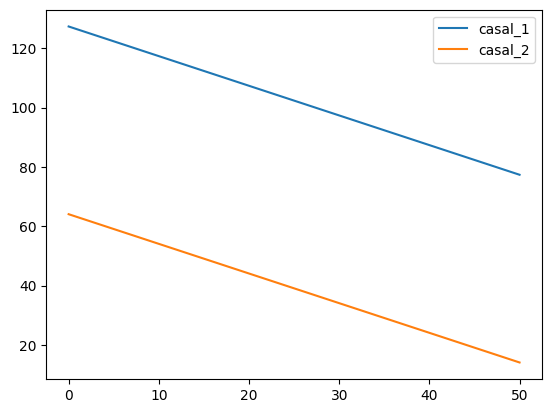

In [34]:
plt.plot(x1_r1, x2_r1, label="casal_1")
plt.plot(x1_r2, x2_r2, label="casal_2")
plt.legend();

In [35]:
x1_r3 = np.array([0, 10, 20 ,30, 40, 50])
x2_r3 = 134.85 - 2 * x1_r3
x2_r3

array([134.85, 114.85,  94.85,  74.85,  54.85,  34.85])

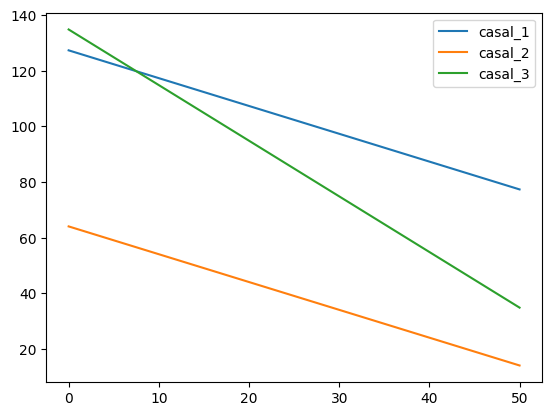

In [36]:
plt.plot(x1_r1, x2_r1, label="casal_1")
plt.plot(x1_r2, x2_r2, label="casal_2")
plt.plot(x1_r3, x2_r3, label="casal_3")
plt.legend();

## Representação de Dados
- Dados tabulares

In [37]:
df = pd.DataFrame({
    "número de bebidas": [1, 2, 2, 2],
    "número de entradas": [1, 2, 1, 1],
    "número de pratos principais": [2, 2, 2, 2],
    "número de sobremesas": [2, 1, 2, 1],
    "valor total do couvert": [10, 10, 10, 10],
    "valor da conta": [127.35, 128.10, 134.85, 119.85]
    },
    index = ['casal_1', 'casal_2', 'casal_3', 'casal_4']
)

In [38]:
df

,número de bebidas,número de entradas,número de pratos principais,número de sobremesas,valor total do couvert,valor da conta
casal_1,1,1,2,2,10,127.35
casal_2,2,2,2,1,10,128.10
casal_3,2,1,2,2,10,134.85
casal_4,2,1,2,1,10,119.85


In [39]:
df_values = df.values

In [40]:
df_values

array([[  1.  ,   1.  ,   2.  ,   2.  ,  10.  , 127.35],
       [  2.  ,   2.  ,   2.  ,   1.  ,  10.  , 128.1 ],
       [  2.  ,   1.  ,   2.  ,   2.  ,  10.  , 134.85],
       [  2.  ,   1.  ,   2.  ,   1.  ,  10.  , 119.85]])

In [41]:
X = df.values[:, 0:5]
X

array([[ 1.,  1.,  2.,  2., 10.],
       [ 2.,  2.,  2.,  1., 10.],
       [ 2.,  1.,  2.,  2., 10.],
       [ 2.,  1.,  2.,  1., 10.]])

In [42]:
y = df_values[:, 5]

In [43]:
instance = df_values[0:1]
instance

array([[  1.  ,   1.  ,   2.  ,   2.  ,  10.  , 127.35]])

In [44]:
instance.shape

(1, 6)

In [45]:
from ucimlrepo import fetch_ucirepo
air_quality = fetch_ucirepo(id=360)

In [46]:
X = air_quality.data.features
X

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,4/4/2005,10:00:00,3.1,1314,-200,13.5,1101,472,539,190,1374,1729,21.9,29.3,0.7568
9353,4/4/2005,11:00:00,2.4,1163,-200,11.4,1027,353,604,179,1264,1269,24.3,23.7,0.7119
9354,4/4/2005,12:00:00,2.4,1142,-200,12.4,1063,293,603,175,1241,1092,26.9,18.3,0.6406
9355,4/4/2005,13:00:00,2.1,1003,-200,9.5,961,235,702,156,1041,770,28.3,13.5,0.5139


In [47]:
measurements = X.loc[:, 'CO(GT)':'AH']
measurements

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,3.1,1314,-200,13.5,1101,472,539,190,1374,1729,21.9,29.3,0.7568
9353,2.4,1163,-200,11.4,1027,353,604,179,1264,1269,24.3,23.7,0.7119
9354,2.4,1142,-200,12.4,1063,293,603,175,1241,1092,26.9,18.3,0.6406
9355,2.1,1003,-200,9.5,961,235,702,156,1041,770,28.3,13.5,0.5139


In [48]:
measurements_array = measurements.values
measurements_array

array([[ 2.600e+00,  1.360e+03,  1.500e+02, ...,  1.360e+01,  4.890e+01,
         7.578e-01],
       [ 2.000e+00,  1.292e+03,  1.120e+02, ...,  1.330e+01,  4.770e+01,
         7.255e-01],
       [ 2.200e+00,  1.402e+03,  8.800e+01, ...,  1.190e+01,  5.400e+01,
         7.502e-01],
       ...,
       [ 2.400e+00,  1.142e+03, -2.000e+02, ...,  2.690e+01,  1.830e+01,
         6.406e-01],
       [ 2.100e+00,  1.003e+03, -2.000e+02, ...,  2.830e+01,  1.350e+01,
         5.139e-01],
       [ 2.200e+00,  1.071e+03, -2.000e+02, ...,  2.850e+01,  1.310e+01,
         5.028e-01]], shape=(9357, 13))

In [49]:
measurements_array.shape

(9357, 13)

In [50]:
measurements_array_corrected = np.expand_dims(measurements_array, axis=1)
measurements_array_corrected

array([[[ 2.600e+00,  1.360e+03,  1.500e+02, ...,  1.360e+01,
          4.890e+01,  7.578e-01]],

       [[ 2.000e+00,  1.292e+03,  1.120e+02, ...,  1.330e+01,
          4.770e+01,  7.255e-01]],

       [[ 2.200e+00,  1.402e+03,  8.800e+01, ...,  1.190e+01,
          5.400e+01,  7.502e-01]],

       ...,

       [[ 2.400e+00,  1.142e+03, -2.000e+02, ...,  2.690e+01,
          1.830e+01,  6.406e-01]],

       [[ 2.100e+00,  1.003e+03, -2.000e+02, ...,  2.830e+01,
          1.350e+01,  5.139e-01]],

       [[ 2.200e+00,  1.071e+03, -2.000e+02, ...,  2.850e+01,
          1.310e+01,  5.028e-01]]], shape=(9357, 1, 13))

In [51]:
measurements_array_corrected.shape

(9357, 1, 13)